# Introduction

*Linear regression* is a statistical technique used to find the relationship between variables. It's the most fundemental model in machine learning. Here will be present Linear Regression from scratch using:
- `numpy` for mathematical calculations
- `matplotlib` & `plotly.express` for visualisation
- `scikit-learn` to compare the result and for built-in dataset

## Future Improvements
- Add multivariate linear regression

# Math

## 1. Linear regression equation

### Math definition
$$y=mx+b$$ 

where
-  $y$ - dependent variable
-  $x$ - independent variable
-  $m$ - **slope** of the line(how much $y$ changes when $x$ increases by 1)
-  $b$ - **y-intercept** (value of $y$ when $x=0$)

### Definition for machine learning
In ML the same equation for a linear regression will be
$$ y' = b + w_1x_1$$ 

where
- $y'$ - predicted **output**
- $x_1$ - **input** feature
- $b$ - **bias(intercept)** of the model. It allows the model to fit data not centered at zero
- $w_1$ - **weight(slope)** of the feature. How strongly each feature affects the output

## 2. Cost function

**Cost Function** guides the model during **training** (optimization objective). The overall measure of model performance used to update parameters. We usually don’t directly “use” the value of $J$ to update the parameters

### Mean Squared Error (MSE)
$$J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

where
* $y_i$ - actual value
* $\hat{y}_i$ - predicted value
* $n$ - number of data points

Often written with $\frac{1}{2n}$ for easier differentiation
$$J(w, b) = \frac{1}{2n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

Instead of just error, we use squared error:
- removes sign (positive/negative canceling)
- makes the function smooth & differentiable
- penalizes large errors more

## 3. Gradient Descent

**Gradient descent** is a mathematical technique that **iteratively** finds the **weights** and **bias** that produce the model with the lowest loss
### Partial Derivatives

For weight $w$:
$$\frac{\partial J}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)x_i$$

For bias $b$:
$$\frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)$$

### Update Rules

$$w = w - \alpha \cdot \frac{\partial J}{\partial w}$$

$$b = b - \alpha \cdot \frac{\partial J}{\partial b}$$

- $\alpha$ - **learning rate**
    - controls how much the model parameters change in response to the error each time the model is updated

## 4. Regularization

**Regularization prevents** **overfitting** by penalizing large weights

### L1 Regularization (Lasso)
Adds absolute weights penalty:

$$J(w, b) = \frac{1}{2n} \sum (\hat{y} - y)^2 + \lambda \sum |w|$$

* Can shrink weights to zero
* Performs feature selection

### L2 Regularization (Ridge)
Adds squared weights penalty:

$$J(w, b) = \frac{1}{2n} \sum (\hat{y} - y)^2 + \lambda \sum w^2$$

* Shrinks weights
* Keeps all features


### Effect on Gradient Descent

**L2 weight update:**
$$w = w - \alpha \left(\frac{\partial J}{\partial w} + 2\lambda w\right)$$

# Implementation

In [1]:
# import
import numpy as np

In [2]:
# Implementation of Simple Linear Regression
class SimpleLinearRegression:
    '''
    Simple Linear Regression implemented using Gradient Descent
    Supports optional L1 (Lasso) and L2 (Ridge) regularization

    Parameters
    ----------
    learning_rate : float, default=0.001
        Step size used to update model parameters during gradient descent
    epochs : int, default=1000
        Number of iterations over the training dataset
    penalty : {'l1', 'l2', None}, default=None
        Type of regularization to apply
    alpha : float, default=0.0
        Regularization strength
    '''

    def __init__(self, learning_rate=0.01, epochs=2000, penalty=None, alpha=0.0):
        # Hyperparameters
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.penalty = penalty
        self.alpha = alpha

        # Model parameters (initialized during training)
        self.weight = None
        self.bias = None

    def fit(self, X, y):
        '''
        Train the linear regression model using gradient descent

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Training feature matrix
        y : ndarray of shape (n_samples,)
            Target values
        '''
        # Init parameters
        # Number of samples and features
        n_samples, n_features = X.shape
        # Initialize weights and bias to zero
        self.weight = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent loop
        for _ in range(self.epochs):
            # 1. Calculate linear equation/prediction
            # y_hat = Xw + b
            y_predicted = np.dot(X, self.weight) + self.bias

            # 2. Computes the gradient
            # If gradient is positive, the parameter is too high -> decrease
            # If gradient is negative, the parameter is too low -> increase
            bias_derivative = (1 / n_samples) * np.sum(y_predicted - y)
            weight_derivative = (1 / n_samples) * np.dot(X.T, (y_predicted - y))

            # 3. Add regularization for derivative if enabled
            if self.penalty == 'l1':
                # L1 adds absolute value penalty (sparse weights)
                weight_derivative += (self.alpha / n_samples) * np.sign(self.weight)
            elif self.penalty == 'l2':
                # L2 adds squared penalty (smooth weights)
                weight_derivative += (self.alpha / n_samples) * self.weight

            # 4. Update model parameters
            # If the gradient is positive -> decrease the parameter
            # If the gradient is negative -> increase the parameter
            self.bias -= self.learning_rate * bias_derivative
            self.weight -= self.learning_rate * weight_derivative

    def predict(self, X):
        '''
        Predict target values using the trained model

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)

        Returns
        -------
        ndarray
            Predicted values
        '''
        return np.dot(np.array(X), self.weight) + self.bias

    def get_params(self):
        '''
        Retrieve model parameters and hyperparameters

        Returns
        -------
        dict
            Dictionary containing weights, bias, and training settings
        '''
        return {
            'weights': self.weight,
            'bias': self.bias,
            'learning_rate': self.learning_rate,
            'epochs': self.epochs,
            'penalty': self.penalty
        }

In [1]:
# Util methods for metrics
def mae_score(y_true, y_pred):  # Mean Absolute Error
    return np.mean(np.abs(y_true - y_pred))

def mse_score(y_true, y_pred): # Mean Squared Error
    return np.mean((y_true - y_pred) ** 2) 

def r2_score(y_true, y_pred):  # R² score
    mean_y = np.mean(y_true)
    ss_total = np.sum((y_true - mean_y) ** 2)
    ss_residual = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_residual / ss_total) if ss_total != 0 else 0

# Model Training, Prediction and Data Visualization

In [4]:
# Import
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_diabetes, make_regression
# TODO write own tran_test_split method
from sklearn.model_selection import train_test_split

The resulting models will be stored in the dictionary for later comparison with the library `scikit-learn`

In [5]:
saved_model = []
separator_str = '---------------------------------------------'

In [6]:
def save_model(name, model, w, b, y_true, y_pred, show_result=False):
    model_data = {
            'name': name,
            'model': model,
            'weight': w,
            'bias': b,
            'mae': mae_score(y_true, y_pred),
            'mse': mse_score(y_true, y_pred),
            'r2': r2_score(y_true, y_pred)
        }
    
    if show_result is False:
        return model_data

    print(separator_str)
    print(name)
    print('The results')
    print(separator_str)
    print(f'weight: {w[0]}')
    print(f'bias: {b}')
    print(f'Full equation: y = {b:.2f} + {w[0]:.2f} * x')
    print(separator_str)
    print(f'Mean Absolute Error: {model_data['mae']}')
    print(f'Mean Squared Error: {model_data['mse']}')
    print(f'R²: : {model_data['r2']}')
    
    return model_data

## Test on a simple dataset 

In [7]:
# Load dataset
path_dataset ='data/study_scores.csv'
study_scores_data = pd.read_csv(path_dataset)

X_study = study_scores_data[['hours']]
y_study = study_scores_data['marks']

# Split into training and testing sets
X_train_study, X_test_study, y_train_study, y_test_study = train_test_split(X_study, y_study, test_size=0.2, random_state=42)

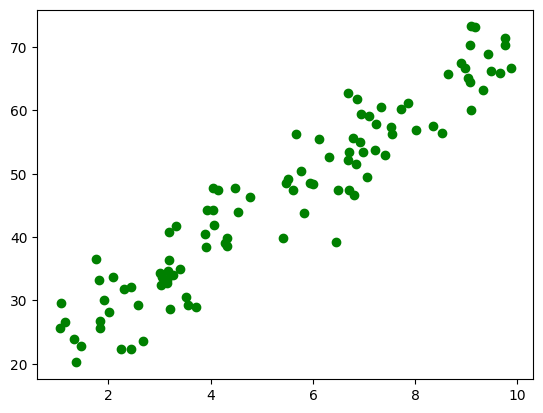

In [9]:
# Visualization of data
plt.scatter(X_study, y_study,color='g')
plt.show()

In [44]:
# Initialize our model
slr_study_model = SimpleLinearRegression(learning_rate= 0.01, epochs = 20000)
# Fit the model
slr_study_model.fit(X_train_study, y_train_study)
# Predict
y_pred_study = slr_study_model.predict(X_test_study)

# Display and save final result
final_slr_study_model = save_model('Linear Regression - Study_Scores Dataset', slr_study_model, slr_study_model.weight, slr_study_model.bias, 
                                   y_test_study, y_pred_study, show_result=True)
saved_model.append(final_slr_study_model)

---------------------------------------------
Linear Regression - Study_Scores Dataset
The results
---------------------------------------------
weight: 5.164438413499701
bias: 18.53857851231634
Full equation: y = 18.54 + 5.16 * x
---------------------------------------------
Mean Absolute Error: 2.9925120459075467
Mean Squared Error: 14.731128407667049
R²: : 0.9258085525213755


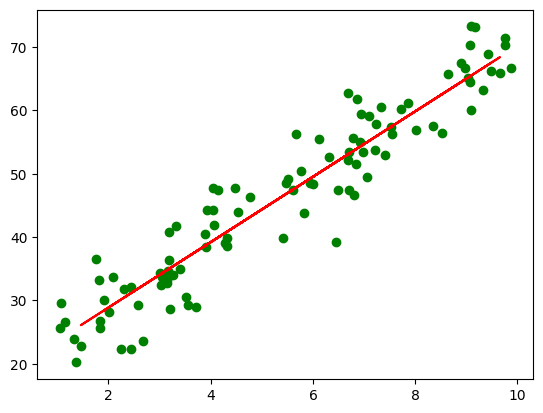

In [45]:
# Visualization of result
plt.scatter(X_study, y_study,color='g')
plt.plot(X_test_study, y_pred_study,color='r')
plt.show()

## TODO - Test on randomly generated dataset using `scikit-learn`

In [47]:
# Load dataset
dummy_regression = make_regression(n_samples=200, n_features=1, noise=5, random_state=40)
X_dummy, y_dummy = dummy_regression[0], dummy_regression[1]

# Split into training and testing sets
X_train_dummy, X_test_dummy, y_train_dummy, y_test_dummy = train_test_split(X_dummy, y_dummy, test_size=0.2, random_state=42)

In [48]:
# Check size of sets
print(f'X_dummy: {X_dummy.shape}')
print(f'y_dummy: {y_dummy.shape}')
print(f'X_train_dummy: {X_train_dummy.shape}')
print(f'y_train_dummy: {y_train_dummy.shape}')
print(f'X_test_dummy: {X_test_dummy.shape}')
print(f'y_test_dummy: {y_test_dummy.shape}')

X_dummy: (200, 1)
y_dummy: (200,)
X_train_dummy: (160, 1)
y_train_dummy: (160,)
X_test_dummy: (40, 1)
y_test_dummy: (40,)


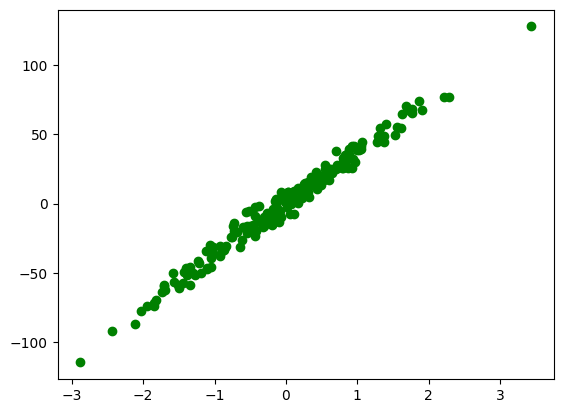

In [49]:
plt.scatter(X_dummy, y_dummy, color='g')
plt.show()

In [52]:
# Initialize our model
slr_dummy_model = SimpleLinearRegression(learning_rate= 0.01, epochs = 20000)
# Fit the model
slr_dummy_model.fit(X_train_dummy, y_train_dummy)
# Predict
y_pred_dummy = slr_study_model.predict(X_test_dummy)

# Display and save final result
final_slr_dummy_model = save_model('Linear Regression - Dummy Dataset', slr_dummy_model, slr_dummy_model.weight, slr_dummy_model.bias, 
                                   y_test_dummy, y_pred_dummy, show_result=True)
saved_model.append(final_slr_dummy_model)

---------------------------------------------
Linear Regression - Dummy Dataset
The results
---------------------------------------------
weight: 37.11344199399806
bias: 0.5975298970227457
Full equation: y = 0.60 + 37.11 * x
---------------------------------------------
Mean Absolute Error: 27.32318593299696
Mean Squared Error: 1213.2780251852876
R²: : -0.09101094776346996


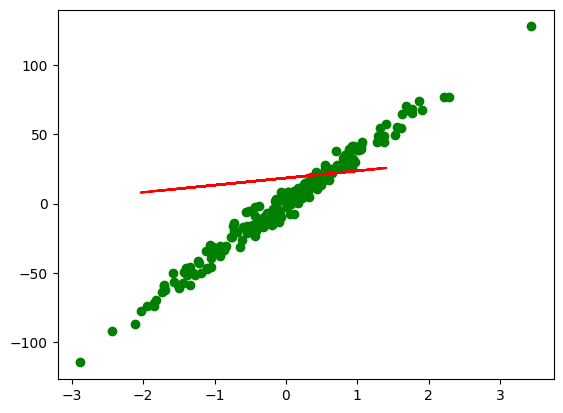

In [53]:
# Visualization of result
plt.scatter(X_dummy, y_dummy,color='g')
plt.plot(X_test_dummy, y_pred_dummy,color='r')
plt.show()

# Comparisons using `scikit-learn`

## Comparison with simple dataset 

In [56]:
# import scikitlearn model
from sklearn.linear_model import LinearRegression

scikit_model_study = LinearRegression()
scikit_model_study.fit(X_train_study, y_train_study)

scikit_pred_study = scikit_model_study.predict(X_test_study)

weights = scikit_model_study.coef_ # weights
bias = scikit_model_study.intercept_ #bias

# Display final result
final_scikit_model_study= save_model('Linear Regression - Scikit Model - Study_Scores', scikit_model_study, weights, bias, 
                                   y_test_study, y_pred_study, show_result=True)

saved_model.append(final_scikit_model_study)

---------------------------------------------
Linear Regression - Scikit Model - Study_Scores
The results
---------------------------------------------
weight: 5.164438413499557
bias: 18.538578512317272
Full equation: y = 18.54 + 5.16 * x
---------------------------------------------
Mean Absolute Error: 2.9925120459075467
Mean Squared Error: 14.731128407667049
R²: : 0.9258085525213755


`np.allclose` checks whether two arrays are numerically equal within a tolerance. It returns True only if all elements of the first array are close to the corresponding elements of the second array

In our case, `True` → predictions are effectively the same

In [55]:
np.allclose(y_pred_study, scikit_pred_study)

True

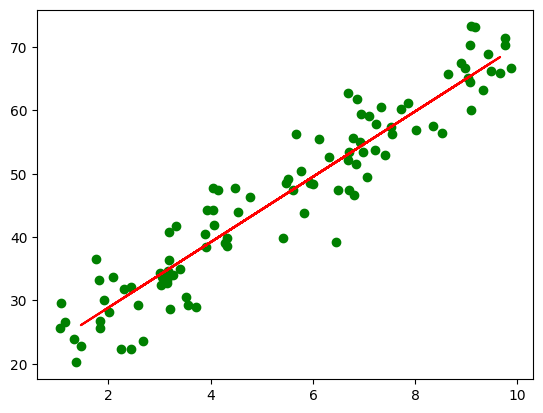

In [43]:
# Visualization of result
plt.scatter(X_study, y_study,color='g')
plt.plot(X_test_study, scikit_pred_study,color='r')
plt.show()

### Analys of result

Scikit-learn is using  the **closed-form solution (Normal Equation)**, when custom model is trained with **gradient descent**. Because of it, custom model has next parameters:
```python
learning_rate = 0.01
epochs = 2000
```

- Normalize X: Gradient descent **needs feature scaling**

```python
X_dummy = (X_dummy - X_dummy.mean()) / X_dummy.std()
```

## TODO - Comparison with randomly generated dataset using `scikit-learn`

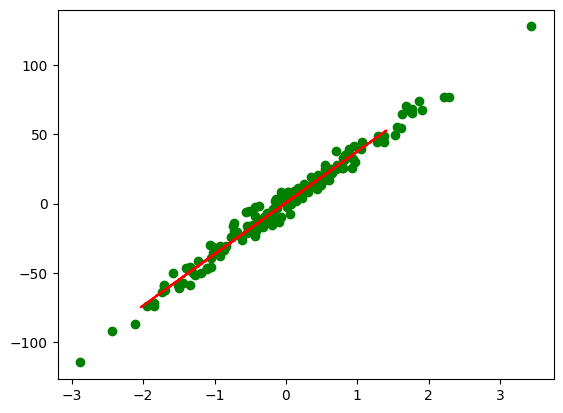

In [19]:
plt.scatter(X_train_dummy, y_train_dummy,color='g')
plt.plot(X_test_dummy, preds_model,color='r')
plt.show()

In [17]:
# import scikitlearn model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_dummy, y_train_dummy)

preds_model = model.predict(X_test_dummy)

weights = model.coef_ # weights
bias = model.intercept_ #bias

print(weights)
print(bias)

print("Dummy Dataset - SKLEARN")
print("----------------")
print("MAE - custom:", mae_score(y_test_dummy, preds_model))
print("MSE - custom:", mse_score(y_test_dummy, preds_model))
print("R² - custom:", r2_score(y_test_dummy, preds_model))

[37.11344199]
0.5975298970227622
Dummy Dataset - SKLEARN
----------------
MAE - custom: 3.4904707316486876
MSE - custom: 19.69729162779189
R² - custom: 0.982287686448513


In [18]:
np.allclose(y_pred_dummy, preds_model)

False